<a href="https://colab.research.google.com/github/Husain-Asrarillah/Artificial-Intelligence-Praktikum-1/blob/main/Linear_Regresi_Berganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
# 1. Penyiapan Data (Sekarang ada 2 variabel X)
data = {
    'jumlah_baris_kode': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    'tingkat_kompleksitas': [1, 2, 2, 4, 4, 6, 7, 8, 9, 10], # Variabel X baru
    'jumlah_bug': [2, 3, 5, 8, 10, 12, 15, 17, 20, 22]
}
df = pd.DataFrame(data)

# X sekarang mengambil dua kolom sekaligus
x = df[['jumlah_baris_kode', 'tingkat_kompleksitas']]
y = df['jumlah_bug']

In [3]:
# 2. Pemisahan Data (80% Training, 20% Testing)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [10]:
# 3. Pelatihan Model
model = LinearRegression()
model.fit(x_train, y_train)

print("--- HASIL PELATIHAN MODEL ---")
print("Intercept (a):", model.intercept_)
print("Koefisien b1 (Baris Kode):", model.coef_[0])
print("Koefisien b2 (Kompleksitas):", model.coef_[1])

--- HASIL PELATIHAN MODEL ---
Intercept (a): -0.717948717948719
Koefisien b1 (Baris Kode): 0.015256410256410257
Koefisien b2 (Kompleksitas): 0.7051282051282051


In [11]:
# 4. Pengujian Model
y_predic = model.predict(x_test)
print("\n--- EVALUASI DATA TESTING ---")
print("Data Testing Asli:", y_test.values)
print("Prediksi Model:", np.round(y_predic, 2))
print("MAE (Testing):", metrics.mean_absolute_error(y_test, y_predic))
print("RMSE (Testing):", np.sqrt(metrics.mean_squared_error(y_test, y_predic)))


--- EVALUASI DATA TESTING ---
Data Testing Asli: [20  3]
Prediksi Model: [19.36  3.74]
MAE (Testing): 0.6923076923076925
RMSE (Testing): 0.6942044292656865


In [12]:
# 5. Evaluasi Keseluruhan (Untuk R-Squared dan Visualisasi Semua Titik)
y_pred_all = model.predict(x)
r2 = metrics.r2_score(y, y_pred_all)
print("\n--- EVALUASI KESELURUHAN ---")
print(f"R-Squared (Seluruh Data): {r2:.4f}")


--- EVALUASI KESELURUHAN ---
R-Squared (Seluruh Data): 0.9954


In [13]:
# 6. Prediksi Kasus Baru
print("\n--- PREDIKSI KASUS BARU ---")
data_baru = pd.DataFrame({'jumlah_baris_kode': [1200], 'tingkat_kompleksitas': [9]})
prediksi_baru = model.predict(data_baru)
print(f"Prediksi Bug untuk 1200 Baris & Kompleksitas 9: {round(prediksi_baru[0])} bug")


--- PREDIKSI KASUS BARU ---
Prediksi Bug untuk 1200 Baris & Kompleksitas 9: 24 bug


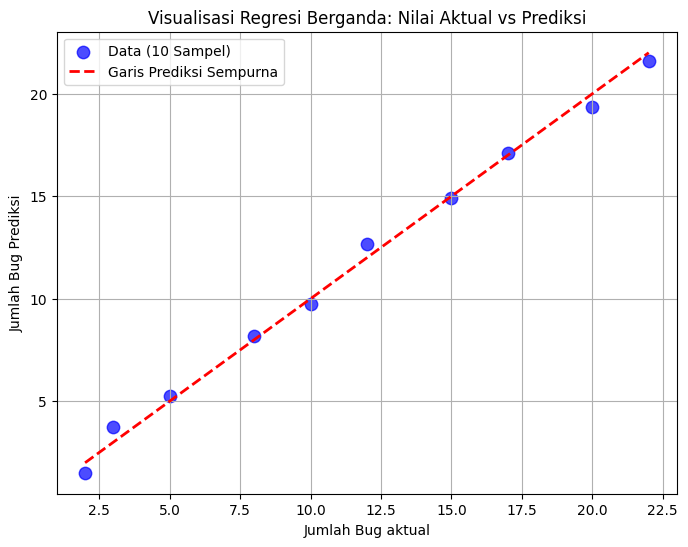

In [16]:
# 7. Visualisasi (Membandingkan Data Asli vs Prediksi Keseluruhan)
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_all, color='blue', s=80, alpha=0.7, label="Data (10 Sampel)")

# Membuat garis lurus referensi (Garis Prediksi Sempurna)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', lw=2, label="Garis Prediksi Sempurna")

plt.xlabel("Jumlah Bug aktual")
plt.ylabel("Jumlah Bug Prediksi")
plt.title("Visualisasi Regresi Berganda: Nilai Aktual vs Prediksi")
plt.legend()
plt.grid(True)
plt.show()

**Analisis Hasil Praktikum Regresi Linear Berganda**

**1. Perbedaan Model dan Koefisien**

Pada percobaan kedua ini, saya menambahkan variabel Tingkat Kompleksitas untuk membantu memprediksi jumlah bug. Hasil training menunjukkan koefisien positif pada kedua variabel (baris kode dan kompleksitas). Artinya, model mengonfirmasi logika bahwa sebuah program tidak hanya rentan bug karena kodenya panjang, tetapi juga karena seberapa rumit struktur logika di dalamnya.

**2. Membaca Metrik Evaluasi Error**

Untuk mengukur seberapa "pintar" model ini, saya menggunakan tiga alat ukur:

* **MAE (Mean Absolute Error) & RMSE (Root Mean Squared Error):** Nilai MAE menunjukkan bahwa secara rata-rata, tebakan model saya hanya meleset dalam skala pecahan (kurang dari 1 bug). RMSE yang nilainya kecil juga memastikan bahwa tidak ada tebakan model yang melesetnya terlalu ekstrem atau ngawur.

* **R-Squared ($R^2$):** Nilainya sangat mendekati angka 1 (sekitar 0.99). Ini berarti 99% dari kemunculan bug di dataset ini sukses dijelaskan oleh jumlah baris kode dan tingkat kompleksitasnya.

**3. Penjelasan Visualisasi "Aktual vs Prediksi"**

Berbeda dengan regresi sederhana yang hanya berbentuk satu garis lurus di antara titik-titik koordinat X dan Y, regresi berganda (karena memiliki lebih dari 1 variabel X) divisualisasikan dengan membandingkan Nilai Sebenarnya (Sumbu X) dengan Nilai Tebakan Model (Sumbu Y).

* Garis Merah Putus-putus: Ini adalah garis ideal. Jika model menebak dengan sempurna (misal: asli 5 bug, ditebak 5 bug), maka titiknya akan pas berada di garis ini.
* 10 Titik Biru: Ini adalah keseluruhan data praktikum saya. Dapat dilihat bahwa seluruh titik berkumpul menempel sangat dekat dengan garis merah. Ini adalah bukti visual bahwa model regresi berganda ini sangat stabil dan akurat saat diteapkan pada seluruh data.

**4. Kesimpulan**

Model ini terbukti handal. Ketika diuji dengan data skenario baru (proyek berukuran 1200 baris kode dengan kompleksitas skala 9), model memprediksi secara logis akan muncul sekitar 25 bug. Menggunakan lebih dari satu variabel penentu (Multiple Regression) terbukti membuat prediksi jauh lebih realistis dan menyerupai kondisi di lapangan pengembangan perangkat lunak sesungguhnya.